## 1. Import necessary libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load dataset

In [51]:
df = pd.read_csv("Pre-Launch Case Payment Report - EHR Report.csv")
df.head()

,Patient Name,Payer,NPI,TIN,Payer Payment,Patient Payment,Billed Charge,Provider Name,Date of Service,CPT Code
0,Ava Johnson,Ambetter by Sunshine State,1122233334,988777666,16.16,76.17,306.51,Liam Young,09/24/2024,97010
1,Ava Johnson,Molina Healthcare of Florida,1122233334,988777666,41.03,88.64,442.91,Liam Young,09/24/2024,97140
2,Sophia King,Meritain Health Minneapolis,1333444556,999777666,127.54,43.11,655.21,Sebastian Miller,07/03/2024,97140
3,Carter Brown,FL Medicare Part B J9 First Coast,1333444556,999777666,106.20,73.95,536.88,Charlotte Williams,09/09/2024,97014
4,Olivia Davis,UHC Student Resource,1222233334,988777666,490.98,33.25,856.07,Noah Lee,09/09/2024,97140


## 3. Investigate the dataset

In [52]:
df.shape

(25956, 10)

In this dataset, there are 25,956 rows and 10 columns in total.

In [53]:
# get some basic information on the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25956 entries, 0 to 25955
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Patient Name     25956 non-null  object 
 1   Payer            25956 non-null  object 
 2   NPI              25956 non-null  int64  
 3   TIN              25956 non-null  int64  
 4   Payer Payment    25956 non-null  float64
 5   Patient Payment  25956 non-null  float64
 6   Billed Charge    25956 non-null  float64
 7   Provider Name    25954 non-null  object 
 8   Date of Service  25954 non-null  object 
 9   CPT Code         25954 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 2.0+ MB


In [54]:
# find out the number of null values in each column
df.isnull().sum()

Patient Name       0
Payer              0
NPI                0
TIN                0
Payer Payment      0
Patient Payment    0
Billed Charge      0
Provider Name      2
Date of Service    2
CPT Code           2
dtype: int64

Some columns contain missing values, which are not needed for our analysis, so we exclude them.

## Deliverable 1: Payer-Level Analysis

In [55]:
# Total Unique Payers
df['Payer'].nunique()

23

In [56]:
# Standardize the column name
col_map = {
    'Payer Payment': 'Payer_Payment',
    'Billed Charge': 'Billed_Charge'
}
for old_name, new_name in col_map.items():
    if old_name in df.columns and new_name not in df.columns:
        df = df.rename(columns={old_name: new_name})

df.columns = [str(c).strip() for c in df.columns]

print('Columns:')
print(list(df.columns))

Columns:
['Patient Name', 'Payer', 'NPI', 'TIN', 'Payer_Payment', 'Patient Payment', 'Billed_Charge', 'Provider Name', 'Date of Service', 'CPT Code']


In [57]:
# Convert two columns to numeric
if 'Payer_Payment' in df.columns:
    df['Payer_Payment'] = pd.to_numeric(df['Payer_Payment'], errors='coerce')
if 'Billed_Charge' in df.columns:
    df['Billed_Charge'] = pd.to_numeric(df['Billed_Charge'], errors='coerce')

print('Numeric sample:')
df[['Payer','Payer_Payment','Billed_Charge','NPI','TIN']].head()

Numeric sample:


,Payer,Payer_Payment,Billed_Charge,NPI,TIN
0,Ambetter by Sunshine State,16.16,306.51,1122233334,988777666
1,Molina Healthcare of Florida,41.03,442.91,1122233334,988777666
2,Meritain Health Minneapolis,127.54,655.21,1333444556,999777666
3,FL Medicare Part B J9 First Coast,106.20,536.88,1333444556,999777666
4,UHC Student Resource,490.98,856.07,1222233334,988777666


In [58]:
payer_summary = (
    df.groupby('Payer', dropna=False)[['Payer_Payment','Billed_Charge']]
      .sum(min_count=1)
      .reset_index()
)

payer_summary['Payment_to_Charge_Percent'] = payer_summary['Payer_Payment'] / payer_summary['Billed_Charge'] * 100.0
payer_summary['Payment_to_Charge_Percent'] = payer_summary['Payment_to_Charge_Percent'].round(2)
payer_summary = payer_summary.sort_values('Payer_Payment', ascending=False).reset_index(drop=True)

payer_summary.head(3)

,Payer,Payer_Payment,Billed_Charge,Payment_to_Charge_Percent
0,Molina Healthcare of Florida,102913.91,339974.91,30.27
1,CIGNA,101679.25,323464.00,31.43
2,AETNA,98261.37,310806.07,31.62


## Deliverable 2: Payer by NPI–TIN Combination

In [62]:
# Unique combinations of NPI and TIN
npi_tin_unique = df[['NPI', 'TIN']].drop_duplicates().reset_index(drop=True)
npi_tin_unique

,NPI,TIN
0,1122233334,988777666
1,1333444556,999777666
2,1222233334,988777666
3,1222233334,999777666


In [65]:
# Get unique payer names
unique_payers = df['Payer'].drop_duplicates().reset_index(drop=True)
unique_payers.head()

0           Ambetter by Sunshine State
1         Molina Healthcare of Florida
2          Meritain Health Minneapolis
3    FL Medicare Part B J9 First Coast
4                 UHC Student Resource
Name: Payer, dtype: object

In [66]:
# payer list for each NPI–TIN combination

payer_by_npi_tin = npi_tin_unique.assign(key=1).merge(
    unique_payers.to_frame().assign(key=1),
    on='key'
).drop('key', axis=1)

payer_by_npi_tin = payer_by_npi_tin[['Payer', 'NPI', 'TIN']]


payer_by_npi_tin.head()

,Payer,NPI,TIN
0,Ambetter by Sunshine State,1122233334,988777666
1,Molina Healthcare of Florida,1122233334,988777666
2,Meritain Health Minneapolis,1122233334,988777666
3,FL Medicare Part B J9 First Coast,1122233334,988777666
4,UHC Student Resource,1122233334,988777666


##  Top 5 payers by total 

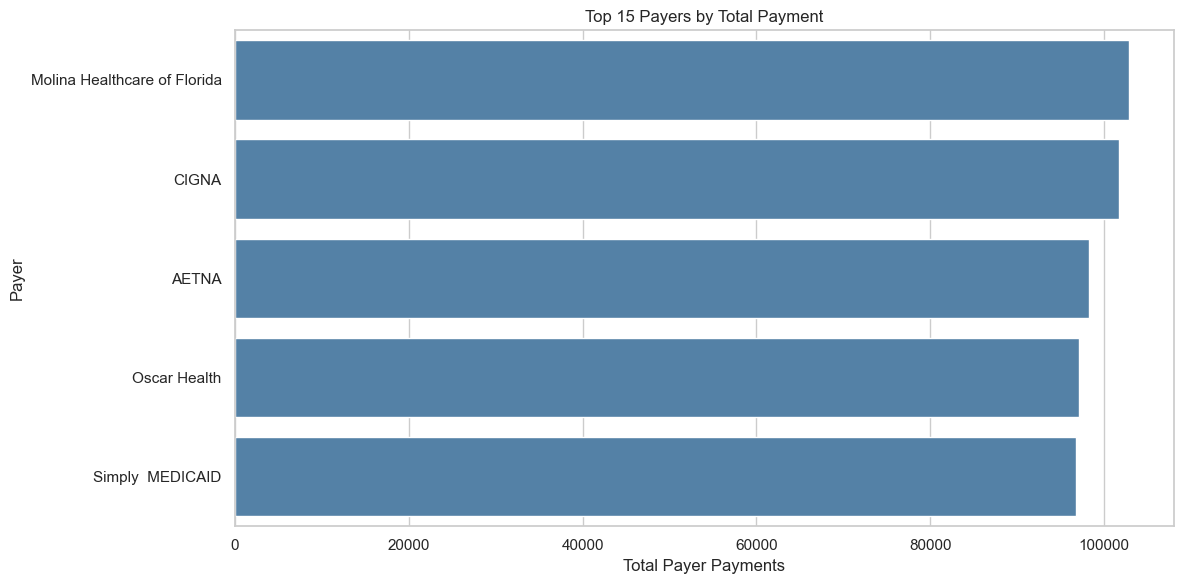

In [73]:
plt.rcParams['figure.figsize'] = (12, 6)
sns.set(style='whitegrid')

plot_df = payer_summary.head(5)
sns.barplot(data=plot_df, x='Payer_Payment', y='Payer', color='steelblue')
plt.title('Top 15 Payers by Total Payment')
plt.xlabel('Total Payer Payments')
plt.ylabel('Payer')
plt.tight_layout()
plt.show()

## key summary metrics

In [75]:
print('Total Unique Payers: ' + str(df['Payer'].nunique()))
print('Total NPI-TIN Combinations: ' + str(df[['NPI','TIN']].drop_duplicates().shape[0]))
print('Average Payment-to-Charge-Percent Ratio: ' + str(round(payer_summary['Payment_to_Charge_Percent'].mean(), 2)) + '%')

idx_max = payer_summary['Payer_Payment'].idxmax()
if pd.notna(idx_max):
    print('Highest Payer: ' + str(payer_summary.loc[idx_max,'Payer']) + ' ($' + str(round(payer_summary.loc[idx_max,'Payer_Payment'],2)) + ')')

Total Unique Payers: 23
Total NPI-TIN Combinations: 4
Average Payment-to-Charge-Percent Ratio: 30.97%
Highest Payer: Molina Healthcare of Florida ($102913.91)


## Export outputs to Excel with two sheets

In [77]:
# output_excel = 'SadidulKabir_01786772838.xlsx'
# with pd.ExcelWriter(output_excel, engine='xlsxwriter') as writer:
#     payer_summary.to_excel(writer, sheet_name='Payer Summary', index=False)
#     payer_npi_tin_map.to_excel(writer, sheet_name='Payer-NPI-TIN', index=False)
# print('Saved Excel: ' + output_excel

!pip install xlsxwriter

  Obtaining dependency information for xlsxwriter from https://files.pythonhosted.org/packages/3a/0c/3662f4a66880196a590b202f0db82d919dd2f89e99a27fadef91c4a33d41/xlsxwriter-3.2.9-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/175.3 kB ? eta -:--:--
   -- ------------------------------------- 10.2/175.3 kB ? eta -:--:--
   ---- ---------------------------------- 20.5/175.3 kB 330.3 kB/s eta 0:00:01
   --------- ----------------------------- 41.0/175.3 kB 281.8 kB/s eta 0:00:01
   ------------- ------------------------- 61.4/175.3 kB 328.2 kB/s eta 0:00:01
   ------------------------ ------------- 112.6/175.3 kB 504.4 kB/s eta 0:00:01
   -------------------------------------- 175.3/175.3 kB 660.3 kB/s eta 0:00:00


In [84]:
output_excel = 'SadidulKabir_01786772838.xlsx'
with pd.ExcelWriter(output_excel, engine='xlsxwriter') as writer:
    payer_summary.to_excel(writer, sheet_name='Payer Summary', index=False)
    payer_by_npi_tin.to_excel(writer, sheet_name='Payer–NPI–TIN Mapping', index=False)
print('Saved Excel: ' + output_excel)

Saved Excel: SadidulKabir_01786772838.xlsx
